In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
%matplotlib inline

In [3]:
df = pd.read_csv("../data/cleaned_songs.csv")

In [4]:
df.shape
df.head()

,name,album,artist,id,release_date,popularity,length,danceability,acousticness,energy,instrumentalness,liveness,valence,loudness,speechiness,tempo,key,time_signature,mood
0,1999,1999,Prince,2H7PHVdQ3mXqEHXcvclTB0,1982-10-27,68,379266,0.866,0.13700,0.730,0.000000,0.0843,0.625,-8.201,0.0767,118.523,5,4,Happy
1,23,23,Blonde Redhead,4HIwL9ii9CcXpTOTzMq0MP,2007-04-16,43,318800,0.381,0.01890,0.832,0.196000,0.1530,0.166,-5.069,0.0492,120.255,8,4,Sad
2,9 Crimes,9,Damien Rice,5GZEeowhvSieFDiR8fQ2im,2006-11-06,60,217946,0.346,0.91300,0.139,0.000077,0.0934,0.116,-15.326,0.0321,136.168,0,4,Sad
3,99 Luftballons,99 Luftballons,Nena,6HA97v4wEGQ5TUClRM0XLc,1984-08-21,2,233000,0.466,0.08900,0.438,0.000006,0.1130,0.587,-12.858,0.0608,193.100,4,4,Happy
4,A Boy Brushed Red Living In Black And White,They're Only Chasing Safety,Underoath,47IWLfIKOKhFnz1FUEUIkE,2004-01-01,60,268000,0.419,0.00171,0.932,0.000000,0.1370,0.445,-3.604,0.1060,169.881,1,4,Energetic


In [27]:
#confirming my choice on not including loudness in features as it is very similar to energy 

features_no_loudness = ["danceability", "energy", "valence", "tempo", "acousticness", "instrumentalness", "speechiness"]

features_with_loudness = ["danceability", "energy", "valence", "tempo", "acousticness", "instrumentalness", "speechiness", "loudness"]

#to scale the audio features for the K-means clustering
X_no_loud = StandardScaler().fit_transform(df[features_no_loudness])
X_with_loud = StandardScaler().fit_transform(df[features_with_loudness])

#keeping the optimal cluster number to 4
opt_k_val = 4

#using the KMeans algorithm method to predict the the silhouette score
no_loud_kmeans = KMeans(n_clusters = opt_k_val, random_state = 42, n_init = 10).fit_predict(X_no_loud)
loud_kmeans = KMeans(n_clusters = opt_k_val, random_state = 42, n_init = 10).fit_predict(X_with_loud)
score_no_loudness = silhouette_score(X_no_loud, no_loud_kmeans)
score_with_loud = silhouette_score(X_with_loud, loud_kmeans)

print(f"Silhouette Score without loudness: {score_no_loudness}")
print(f"Silhouette Score with loudness: {score_with_loud}")

Silhouette Score without loudness: 0.26314130376464906
Silhouette Score with loudness: 0.23708580647939412


For code cell above, I began to begin scaling the features I need for K-means clustering model. Since I attempt to answer the question of "Do clusters formed from audio features correspond to overall moods?" In the dataset, there were these audio features already present: danceability, energy, valence, tempo, acousticness, instrumentalness, speechiness, and loudness. However, one thing I noticed that loudness and energy are very similar and didn't want the K-means clustering to count for it twice. So in order to compare whether or not I should include loudness in my scaled features for the k-means clustering, I scaled both of them and compared which one performed better. And since the silhouette score without loudness had a number of 0.2631. And since it is more closer to 1 then with the loudness feature, it shows that there seems to be more of an apparent cluster bordering, confirming my earlier decision in the beginning cell.

In [54]:
#selecting the features + scaling them

features = ["danceability", "energy", "valence", "tempo", "acousticness", "instrumentalness", "speechiness"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(686, 7)


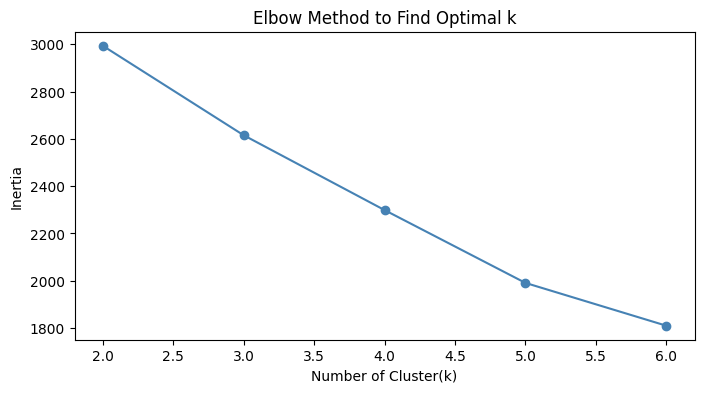

In [55]:
#Elbow method
elbow_inertia = []
k_range = range(2, 7)

for k in k_range:
    k_means = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    k_means.fit(X_scaled)
    elbow_inertia.append(k_means.inertia_)

plt.figure(figsize = (8, 4))
plt.plot(k_range, elbow_inertia, marker='o', color = 'steelblue')
plt.xlabel("Number of Cluster(k)")
plt.ylabel("Inertia")
plt.title("Elbow Method to Find Optimal k")
plt.savefig("../plots/elbow_plot.png", dpi=150)
plt.show()

For the elbow method visualization above, I was expected a sharp bend shape of the line for this graph. However, after running the code from above with the random state of 42 and initialized it to 10 to make the cluster producing reproducible. And through the line plot above, it is showing a gradual decreasing pattern which doesn't show me a clear answer of what my k value should be. Through the elbow method, if there was a sharp bend at one singular point, it would clearly tell what k value is optimal. But since this method didn't show me a definitive answer, I concluded that I would need to use another method to find the optimal k value. 

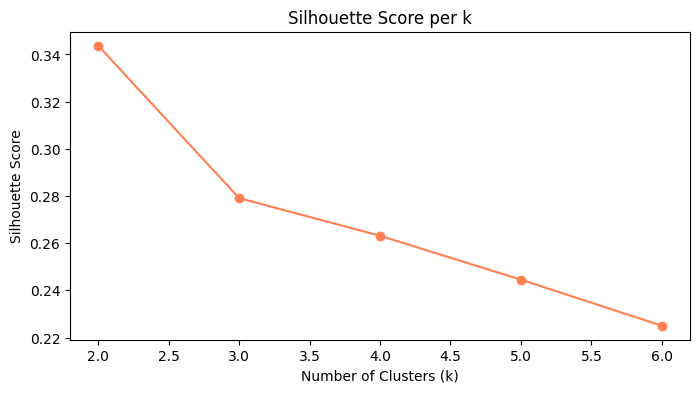

In [56]:
#silhouette score per k
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,4))
plt.plot(k_range, silhouette_scores, marker='o', color='coral')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per k")
plt.savefig("../plots/silhouette_per_k.png", dpi=150)
plt.show()

    

Since the Elbow method didn't give me sufficient information on what value of K I should use for the clustering, I decided to explore the Silhouette Score method since this one mathematically decides through using its range from -1 to 1. So basically if the silhouette number is closer to 1, then that means that the songs are farther away from other clusters and will have perfect grouping among the members of its own cluster group which is good. However, if the number is closer to 0 then that means it is overlapping and their is no clear clusters separating between the songs. Thus from the line plot above, I can tell that with a silhouette score of 0.34, it recommends k=2. And since k=2 is not enough number of clusters to come up with meaningful analysis, I decided to make a judgement call to finally choose k=4.

In [57]:
#final K-Means Model
opt_k_val = 4
kmeans_model = KMeans(n_clusters = opt_k_val, random_state = 42, n_init = 10)
df["cluster"] = kmeans_model.fit_predict(X_scaled)

#to show how many of the songs are within each cluster.
print(df["cluster"].value_counts())
df.to_csv("../data/clustered_spotify.csv", index = False)


cluster
2    306
3    219
1    130
0     31
Name: count, dtype: int64


In [58]:
#final silhouette score
score = silhouette_score(X_scaled, df["cluster"])
print(f"Silhouette Score: {score}")

Silhouette Score: 0.26314130376464906


In [59]:
#testing multiple seeds to make sure my K-means model is stable and reproducible

#multiple seeds - 10 random seeds across a wide range 
# to show that model is stable across
seeds = [0, 7, 21, 42, 84, 100, 123, 200, 255, 300]
stability_res = []

#looping through each seed within the seeds list
for seed in seeds:
    #same 4 clusters, but setting random_state to each seed
    km = KMeans(n_clusters=4, random_state=seed, n_init=10) 
    labels = km.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)

    stability_res.append({"Random Seed": seed, "Silhouette Score": round(score, 4)})

    stabil_df = pd.DataFrame(stability_res)
    print(stabil_df)

   Random Seed  Silhouette Score
0            0            0.2631
   Random Seed  Silhouette Score
0            0            0.2631
1            7            0.2631
   Random Seed  Silhouette Score
0            0            0.2631
1            7            0.2631
2           21            0.2631
   Random Seed  Silhouette Score
0            0            0.2631
1            7            0.2631
2           21            0.2631
3           42            0.2631
   Random Seed  Silhouette Score
0            0            0.2631
1            7            0.2631
2           21            0.2631
3           42            0.2631
4           84            0.2631
   Random Seed  Silhouette Score
0            0            0.2631
1            7            0.2631
2           21            0.2631
3           42            0.2631
4           84            0.2631
5          100            0.2631
   Random Seed  Silhouette Score
0            0            0.2631
1            7            0.2631
2         

In [60]:
#To compare K-Means clustering with Agglomerative Clustering to see which one works best for this analysis.
from sklearn.cluster import AgglomerativeClustering

agg_method = AgglomerativeClustering(n_clusters=4)
labels = agg_method.fit_predict(X_scaled)

agg_score = silhouette_score(X_scaled, labels)

#got this number from a few cells above
print(f"K-Means: 0.2631") 
print(f"Agglomerative: {agg_score}")

if 0.2631 > agg_score:
    print("\nK-Means performed better for this dataset")
else:
    print("\nAgglomerative performed better for this dataset")

K-Means: 0.2631
Agglomerative: 0.24670246341998792

K-Means performed better for this dataset


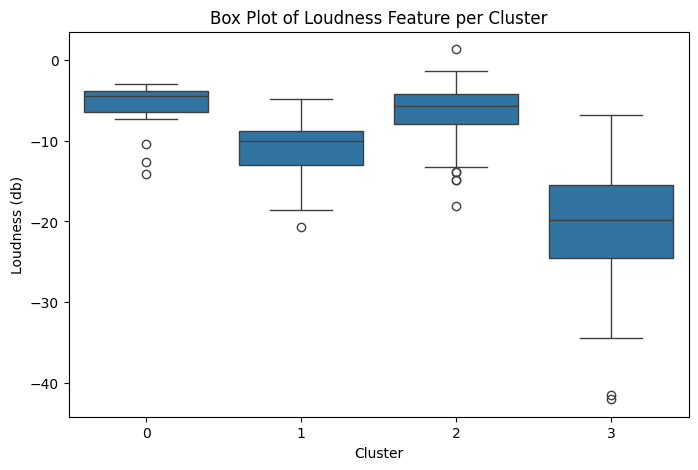

In [61]:
feature = 'loudness'
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y=feature, data=df)
plt.title("Box Plot of Loudness Feature per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Loudness (db)")
plt.savefig("../plots/loudness_boxplot.png", dpi=150)
plt.show()

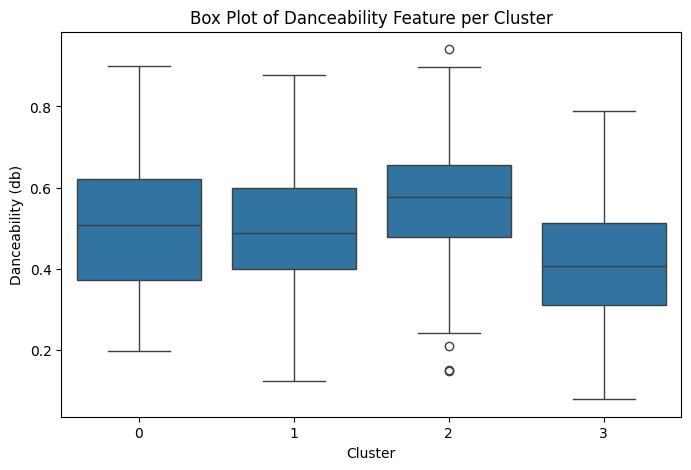

In [62]:
feature = 'danceability'
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y=feature, data=df)
plt.title("Box Plot of Danceability Feature per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Danceability (db)")
plt.savefig("../plots/danceability_boxplot.png", dpi=150)
plt.show()

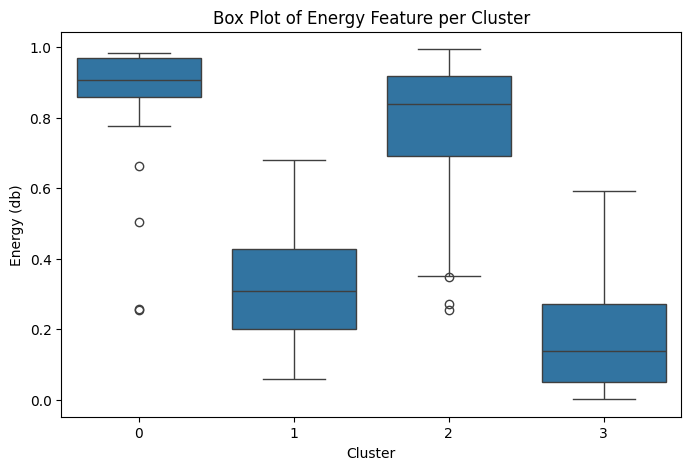

In [63]:
feature = 'energy'
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y=feature, data=df)
plt.title("Box Plot of Energy Feature per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Energy (db)")
plt.savefig("../plots/energy_boxplot.png", dpi=150)
plt.show()

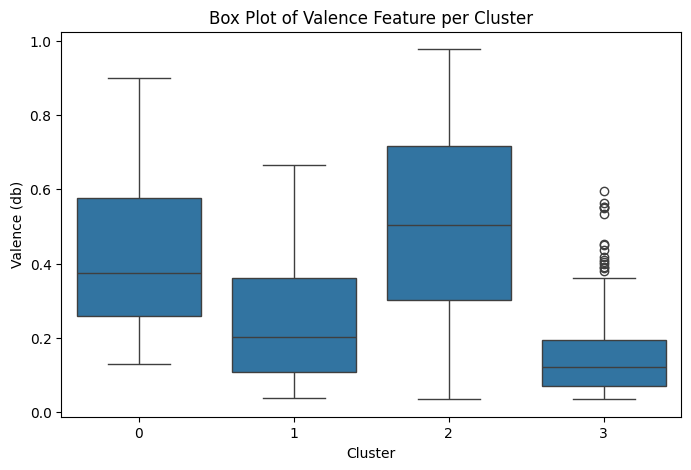

In [64]:
feature = 'valence'
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y=feature, data=df)
plt.title("Box Plot of Valence Feature per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Valence (db)")
plt.savefig("../plots/valence_boxplot.png", dpi=150)
plt.show()

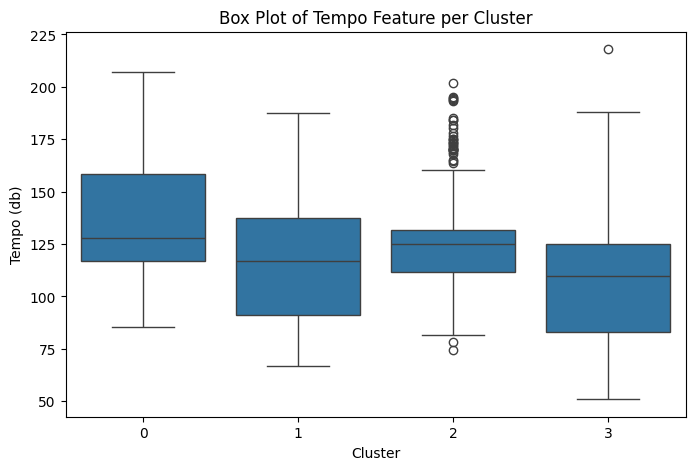

In [65]:
feature = 'tempo'
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y=feature, data=df)
plt.title("Box Plot of Tempo Feature per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Tempo (db)")
plt.savefig("../plots/tempo_boxplot.png", dpi=150)
plt.show()

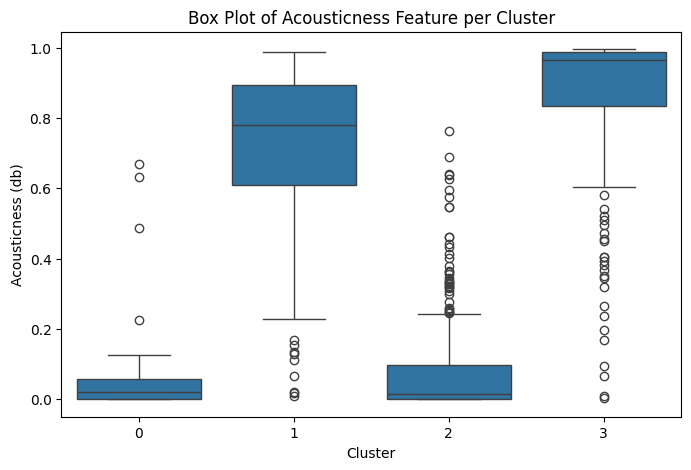

In [66]:
feature = 'acousticness'
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y=feature, data=df)
plt.title("Box Plot of Acousticness Feature per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Acousticness (db)")
plt.savefig("../plots/acousticness_boxplot.png", dpi=150)
plt.show()

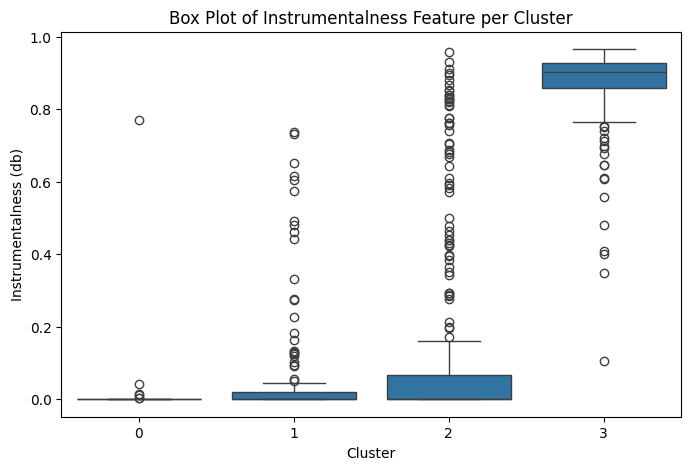

In [67]:
feature = 'instrumentalness'
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y=feature, data=df)
plt.title("Box Plot of Instrumentalness Feature per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Instrumentalness (db)")
plt.savefig("../plots/instrumentalness_boxplot.png", dpi=150)
plt.show()

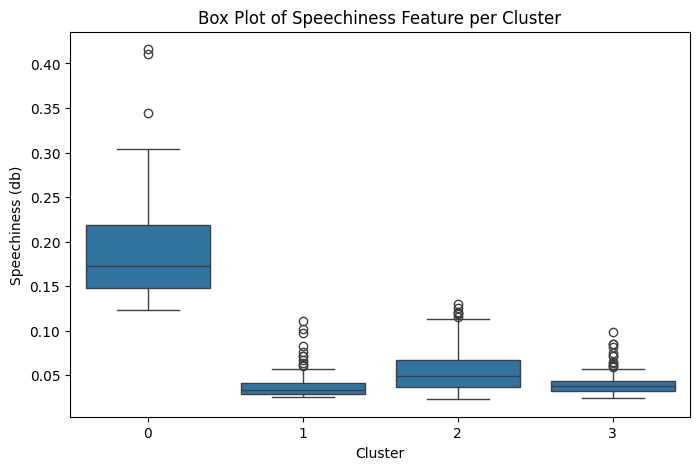

In [68]:
feature = 'speechiness'
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y=feature, data=df)
plt.title("Box Plot of Speechiness Feature per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Speechiness (db)")
plt.savefig("../plots/speechiness_boxplot.png", dpi=150)
plt.show()

         danceability    energy   valence       tempo  acousticness  \
cluster                                                               
0            0.510677  0.851645  0.423871  136.478935      0.088607   
1            0.493708  0.318657  0.250015  115.803346      0.707031   
2            0.569095  0.789595  0.505852  126.498147      0.083217   
3            0.407412  0.177330  0.157441  108.368379      0.860286   

         instrumentalness  speechiness  
cluster                                 
0                0.027376     0.202839  
1                0.066618     0.038929  
2                0.127986     0.055209  
3                0.872877     0.040019  


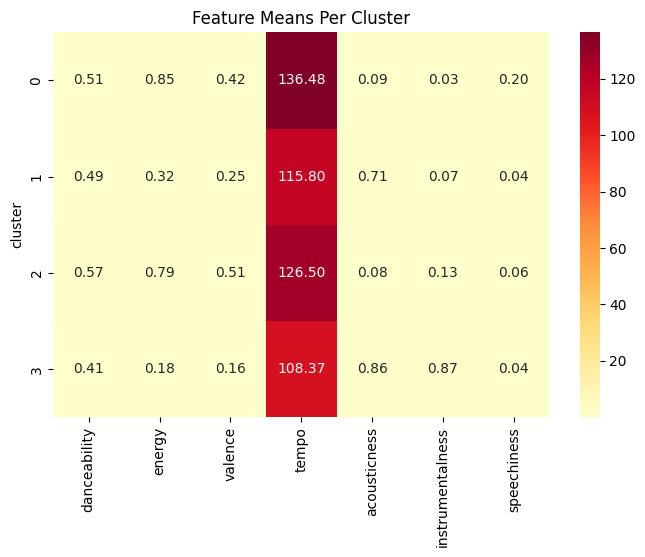

In [69]:
all_clusters = df.groupby("cluster")[features].mean()
print(all_clusters)

plt.figure(figsize = (8, 5))
sns.heatmap(all_clusters, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Feature Means Per Cluster")
plt.savefig("../plots/feature_means_heatmap.png", dpi=150)
plt.show()

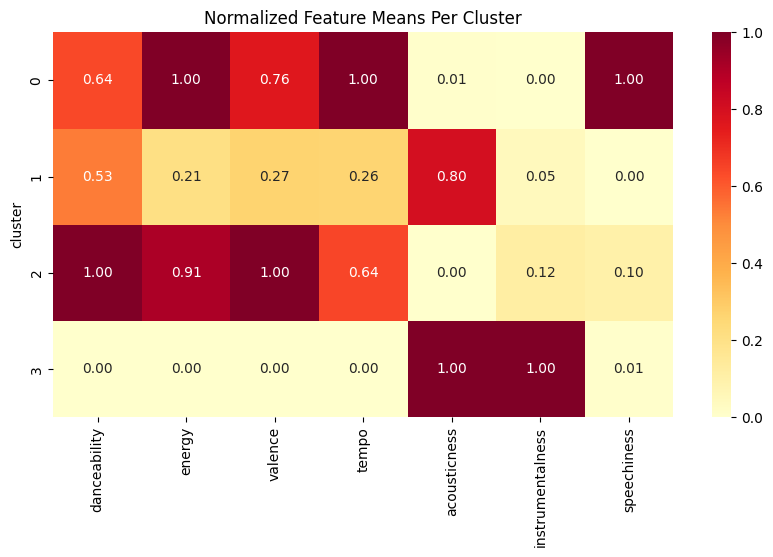

In [70]:
#normalizing cluster profile for the visualization since above
#makes it look like tempo is really important compared to other features
#and scaling is off
from sklearn.preprocessing import MinMaxScaler

min_scaler = MinMaxScaler()
cluster_profile_normalized = pd.DataFrame(
    min_scaler.fit_transform(all_clusters),
    columns = all_clusters.columns,
    index = all_clusters.index
)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile_normalized, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Normalized Feature Means Per Cluster")
plt.savefig("../plots/feature_means_heatmap_normalized.png", dpi=150)
plt.show()


mood     Calm  Energetic  Happy  Sad
cluster                             
0           0         19      9    3
1           1          1      5  123
2           3        134    126   43
3         191          0      0   28


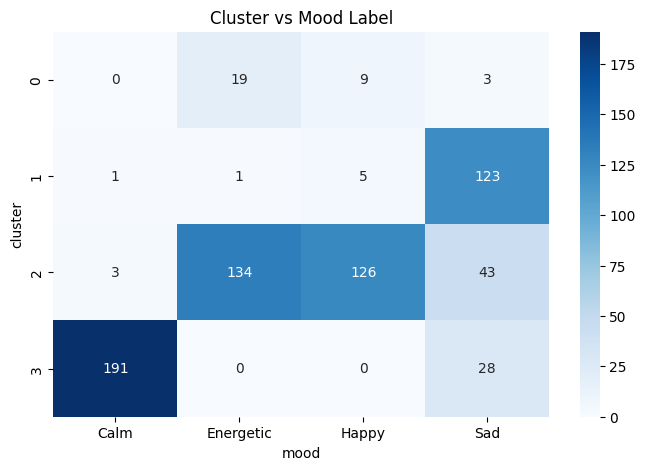

In [71]:
comparison = df.groupby(['cluster', 'mood']).size().unstack(fill_value= 0)
print(comparison)

plt.figure(figsize=(8, 5))
sns.heatmap(comparison, annot = True, fmt = "d", cmap = "Blues")
plt.title("Cluster vs Mood Label")
plt.savefig("../plots/mood_heatmap.png", dpi=150)
plt.show()

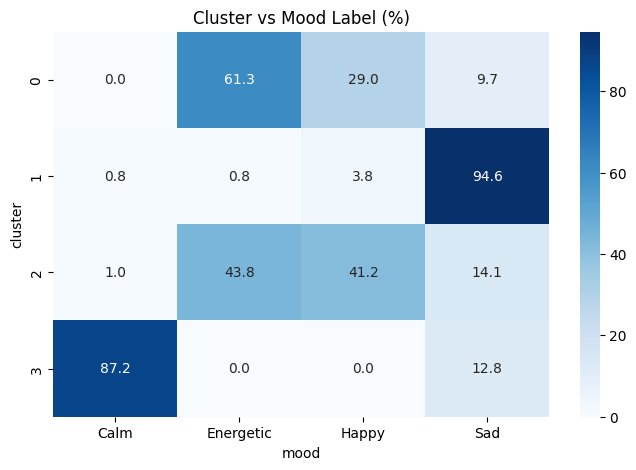

In [72]:
mood_counts = df.groupby(['cluster', 'mood']).size().unstack(fill_value = 0)
pct_groupby = mood_counts.apply(lambda x: 100 * x/x.sum(), axis = 1)

plt.figure(figsize = (8,5))
sns.heatmap(pct_groupby, annot = True, fmt = ".1f", cmap="Blues")
plt.title("Cluster vs Mood Label (%)")
plt.savefig("../plots/mood_heatmap_pct.png", dpi = 150)
plt.show()

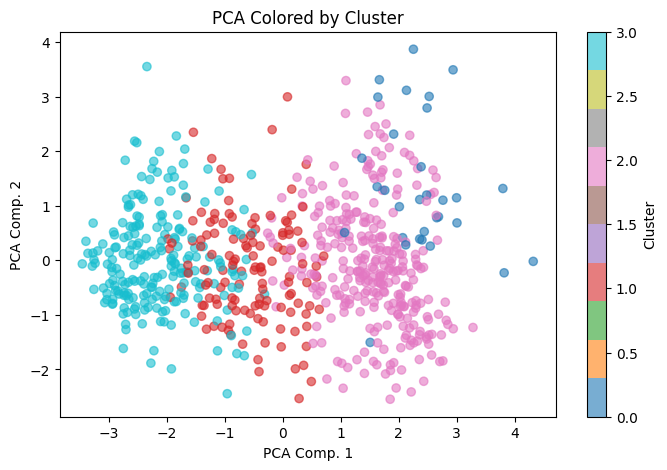

In [73]:
#PCA colored by cluster
pca = PCA(n_components = 2) 
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))

#X-axis and y-axis
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c = df["cluster"], cmap = "tab10", alpha = 0.6)

plt.colorbar(scatter, label="Cluster")
plt.title("PCA Colored by Cluster")
plt.xlabel("PCA Comp. 1")
plt.ylabel("PCA Comp. 2")
plt.savefig("../plots/pca_cluster.png", dpi=150)
plt.show()

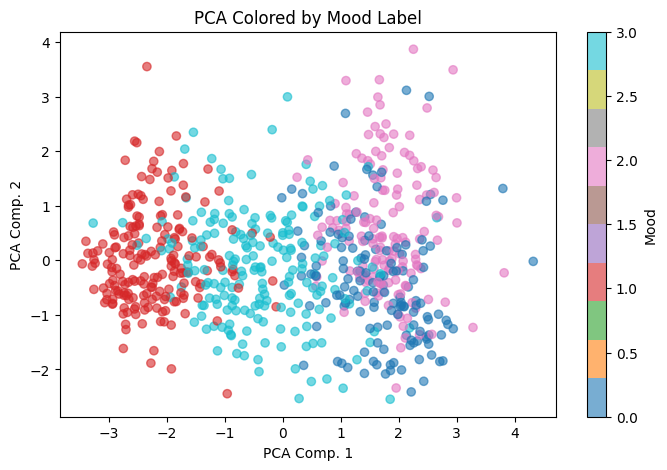

In [74]:
#PCA colored by mood
mood_map = {"Happy": 0, "Calm": 1, "Energetic": 2, "Sad": 3}
df["mood_code"] = df["mood"].map(mood_map)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["mood_code"], cmap="tab10", alpha=0.6)
plt.colorbar(scatter, label="Mood")
plt.title("PCA Colored by Mood Label")
plt.xlabel("PCA Comp. 1")
plt.ylabel("PCA Comp. 2")
plt.savefig("../plots/pca_mood.png", dpi=150)
plt.show()


In [76]:
#recommendation system
from sklearn.metrics.pairwise import cosine_similarity
def recommend_songs(song_title, df, X_scaled, n=5):
    try:
        song_index = df[df["name"] == song_title].index[0]
        song_cluster = df.loc[song_index, "cluster"]
        song_mood = df.loc[song_index, "mood"]
        song_artist = df.loc[song_index, "artist"]

        #mapping each cluster to a mood
        cluster_name_mood = {0: "Energetic", 1: "Sad", 2: "Happy", 3: "Calm"}

        #laying out the output
        print(f"Input Song: {song_title}")
        print(f"Artist: {song_artist}")
        print(f"Labeled Mood: {song_mood}")
        print(f"Cluster: {song_cluster} ({cluster_name_mood[song_cluster]})")
        print(f"Cluster Size: {len(df[df['cluster'] == song_cluster])} songs")

        #filtering to the same cluster
        cluster_mask = df["cluster"] == song_cluster
        cluster_indices = df[cluster_mask].index
        
        #doing cosine similarity within each cluster to get similar songs
        similarities = cosine_similarity([X_scaled[song_index]], X_scaled[cluster_mask])[0]
        
        #get the top n (5) songs
        top_n_songs = similarities.argsort()[::-1][1:n+1]
        recommendations = df.iloc[cluster_indices[top_n_songs]][["name", "artist", "mood", "cluster"]].copy()

        #adding similarity score for each of the recommendations
        recommendations["similarity_score"] = similarities[top_n_songs].round(3)

        #resetting the index for a cleaner output
        recommendations = recommendations.reset_index(drop=True)
        recommendations.index += 1

        return recommendations
    except IndexError:
        return "Song not found"
    

cluster_names = {0: "Energetic", 1: "Sad", 2: "Happy", 3: "Calm"}

for cluster_id in range(4):
    print(f"CLUSTER {cluster_id} — {cluster_names[cluster_id]}")
    sample = df[df["cluster"] == cluster_id]["name"].iloc[0]
    result = recommend_songs(sample, df, X_scaled)
    if isinstance(result, str):
        print(result)
    else:
        print(result.to_string())
    print()



CLUSTER 0 — Energetic
Input Song: A Place for My Head
Artist: Linkin Park
Labeled Mood: Energetic
Cluster: 0 (Energetic)
Cluster Size: 31 songs
                                        name            artist       mood  cluster  similarity_score
1                  You Can't Rely on My Love           Mordkey      Happy        0             0.982
2                                      Toxic  A Static Lullaby  Energetic        0             0.973
3         Sun In Our Eyes - Don Diablo Remix                MØ      Happy        0             0.970
4  Waiting For Tomorrow (feat. Mike Shinoda)     Martin Garrix  Energetic        0             0.963
5                            Highway to Hell             AC/DC      Happy        0             0.962

CLUSTER 1 — Sad
Input Song: 9 Crimes
Artist: Damien Rice
Labeled Mood: Sad
Cluster: 1 (Sad)
Cluster Size: 130 songs
                       name          artist mood  cluster  similarity_score
1             Long Way Down       Tom Odell  Sad        1